In [3]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

Для начала посмотрим, как примерно выглядит датасет

In [4]:
df = pd.read_csv('city_clients.csv')
df.head()

,party_rk,gorod_client_flg,fuel_gmv,fuel_avg_price,fuel_n_orders,fuel_first_order_date,fuel_last_order_date,supermarket_gmv,supermarket_avg_price,supermarket_n_orders,...,kino_gmv,kino_transactions_cnt,arenda_avto_gmv,arenda_avto_transactions_cnt,knigi_gmv,knigi_transactions_cnt,zhivotnye_gmv,zhivotnye_transactions_cnt,turagentstva_gmv,turagentstva_transactions_cnt
0,1002611776,1,1499.06,749.530000,2.0,2023-05-22,2024-07-08,NaN,NaN,NaN,...,798.0,128.0,0.0,128.0,0.0,128.0,0.0,128.0,0.0,128.0
1,812910044,1,5600.68,1866.893333,3.0,2023-01-12,2024-03-30,NaN,NaN,NaN,...,0.0,92.0,0.0,92.0,0.0,92.0,0.0,92.0,0.0,92.0
2,379196768,1,32831.06,1492.320909,22.0,2023-08-12,2024-09-28,3775.76,1887.88,2.0,...,512.0,457.0,0.0,457.0,0.0,457.0,0.0,457.0,21680.0,457.0
3,695174271,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,292.0,0.0,292.0,0.0,292.0,0.0,292.0,0.0,292.0
4,843828836,1,NaN,NaN,NaN,NaN,NaN,1687.82,1687.82,1.0,...,0.0,528.0,0.0,528.0,0.0,528.0,0.0,528.0,0.0,528.0


In [5]:
print('Клиенты города:', df[df['gorod_client_flg'] == 1].shape[0] / len(df) * 100, '%')

Клиенты города: 50.0 %


Наивные предположения: принадлежность к клиентам сервиса зависит от характеристик человека. Посмотрим на самые базовые (пол, возраст). Также важно понимать, какие сервисы города пользуются наибольшей популярностью, и есть ли какая-то корреляция между использованием двух различных сервисов и их комбинации.

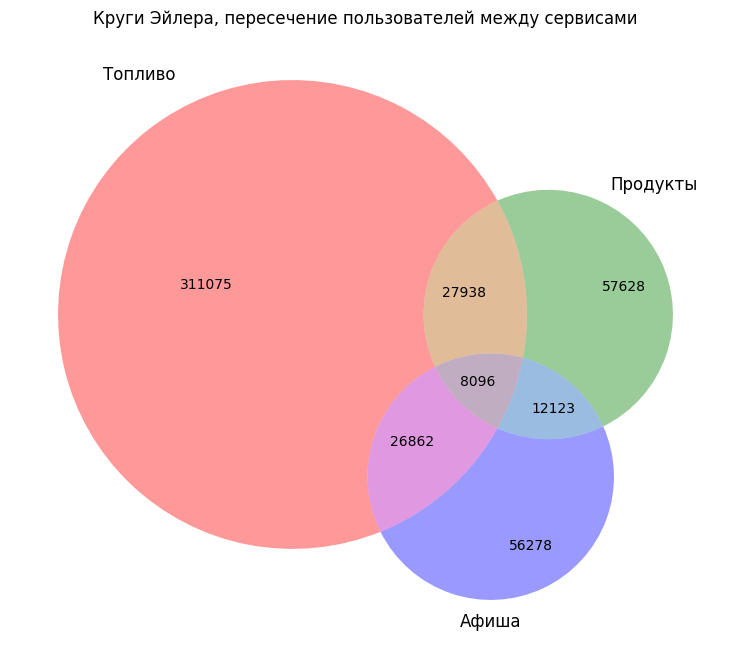

In [6]:
from matplotlib_venn import venn3

fuel_users = set(df[df['fuel_n_orders'].notna()].index)
supermarket_users = set(df[df['supermarket_n_orders'].notna()].index)
afisha_users = set(df[df['afisha_n_orders'].notna()].index)

plt.figure(figsize=(10, 8))
venn3([fuel_users, supermarket_users, afisha_users], 
      ['Топливо', 'Продукты', 'Афиша'])
plt.title('Круги Эйлера, пересечение пользователей между сервисами')
plt.show()

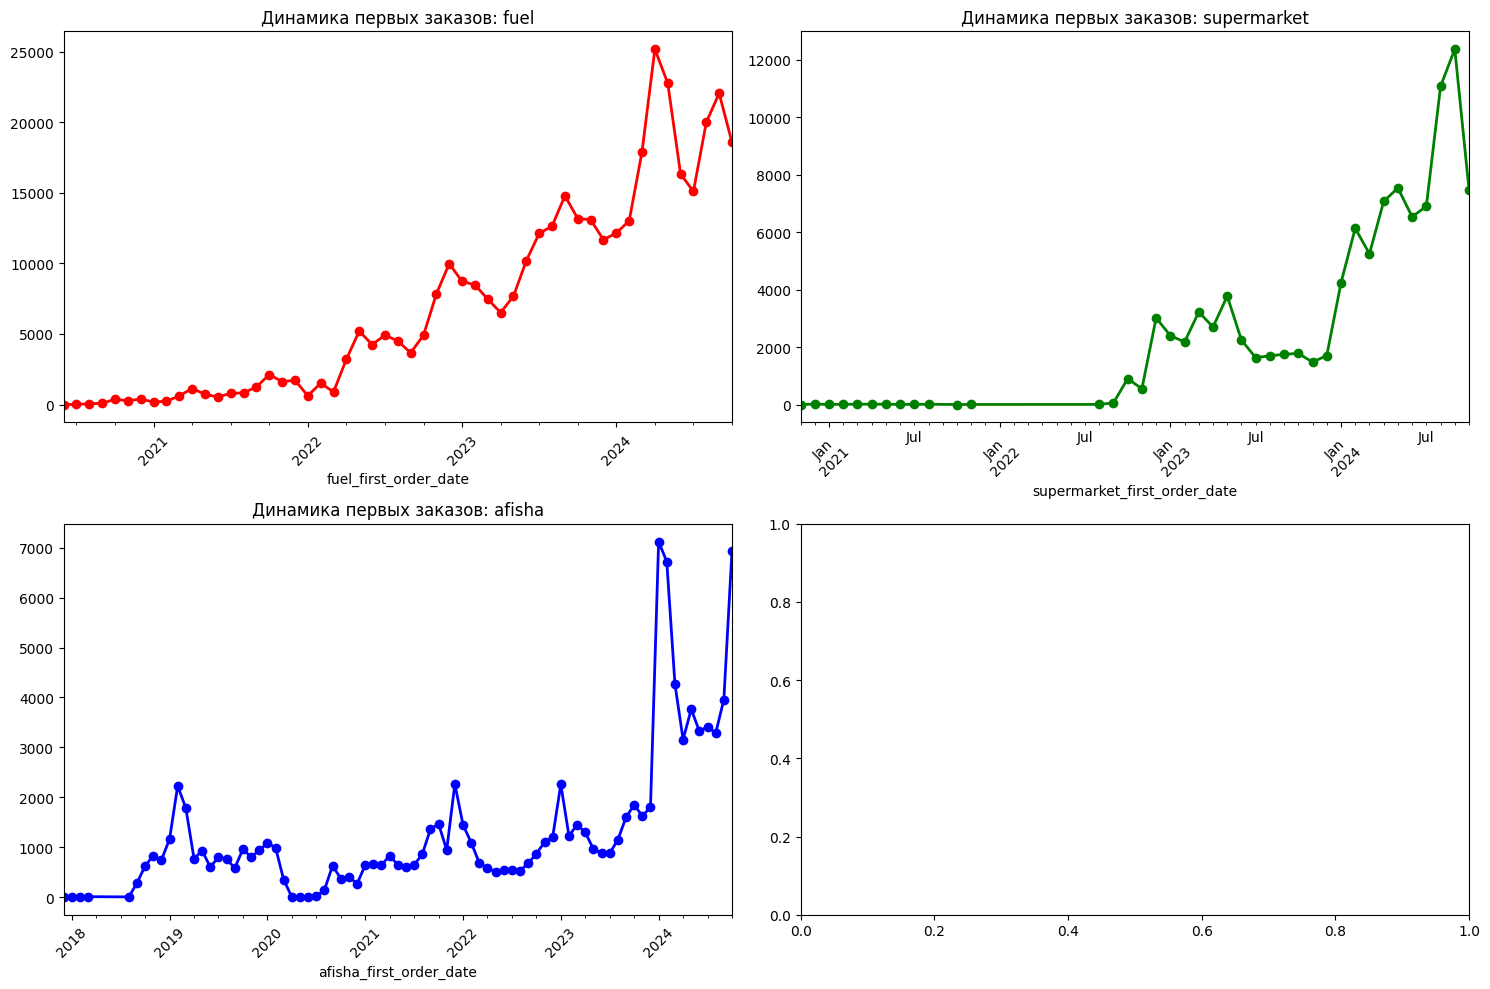

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

services = enumerate(['fuel', 'supermarket', 'afisha'])
colors = ['red', 'green', 'blue']

for i, service in services:
    date_col = f'{service}_first_order_date'
    if date_col in df.columns:
        monthly_signups = pd.to_datetime(df[date_col]).dt.to_period('M').value_counts().sort_index()
        monthly_signups.plot(ax=axes[i//2, i%2], color=colors[i], linewidth=2, marker='o')
        axes[i//2, i%2].set_title(f'Динамика первых заказов: {service}')
        axes[i//2, i%2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Траты в Афише повышаются в новый год и понижаются летом. Возможно, нужно предлагать билеты на популярные летние фестивали (наприме, музыкальный фестиваль 'Улетай' или разрекламированный недавно праздник огурца в Суздале)

Гипотеза:
***
Предлагать или рекламировать в 'Афише' летние фестивали, чтобы повысить траты пользователей не только во время новогодних праздников, что повлечёт за собой повышение количества первых заказов в летнее время.
***

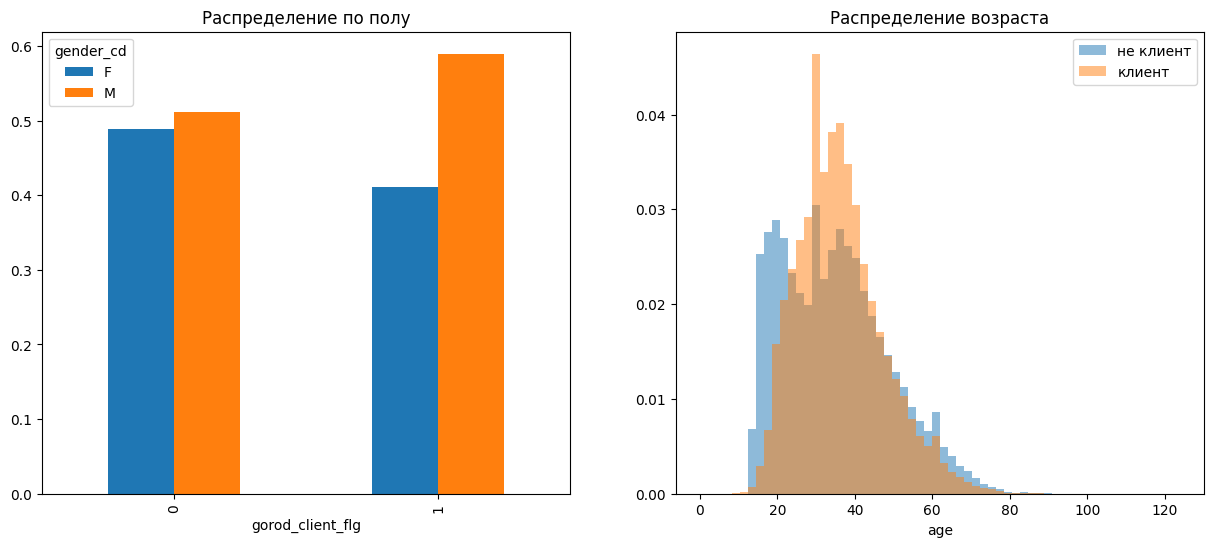

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
df.groupby('gorod_client_flg')['gender_cd'].value_counts(normalize=True).unstack().plot(kind='bar', title='Распределение по полу', ax=axes[0])

ages0 = df.loc[df['gorod_client_flg'] == 0, 'age'].dropna()
ages1 = df.loc[df['gorod_client_flg'] == 1, 'age'].dropna()

axes[1].hist(ages0, bins=60, alpha=0.5, label='не клиент', color='C0', density=True)
axes[1].hist(ages1, bins=60, alpha=0.5, label='клиент', color='C1', density=True)
axes[1].set_title('Распределение возраста')
axes[1].set_xlabel('age')
axes[1].legend()

Из первого графика видно, что мужчины чаще становятся клиентами. 

Второй график показался мне интересным. По нему понятно, что стоит активнее привлекать клиентов до 25 лет (так как в остальном распределения похожи, а на промежутке [18, 21] разница заметна). С другой стороны, такие клиенты, возможно, обладают меньшей платежеспособностью, и их массовое привлечение принесёт меньше прибыли, чем привлечение меньшей по размеру, но большей по тратам группы клиентов. Поэтому стоит посмотреть также на зависимость присоединения к "городу" от средних трат. Также важно посмотреть на корреляцию с интересами. Так, например, люди от 18 до 21 года вероятно, в среднем реже владеют автомобилем, и, как следствие, не тратят финансы в сервисе 'топливо'.

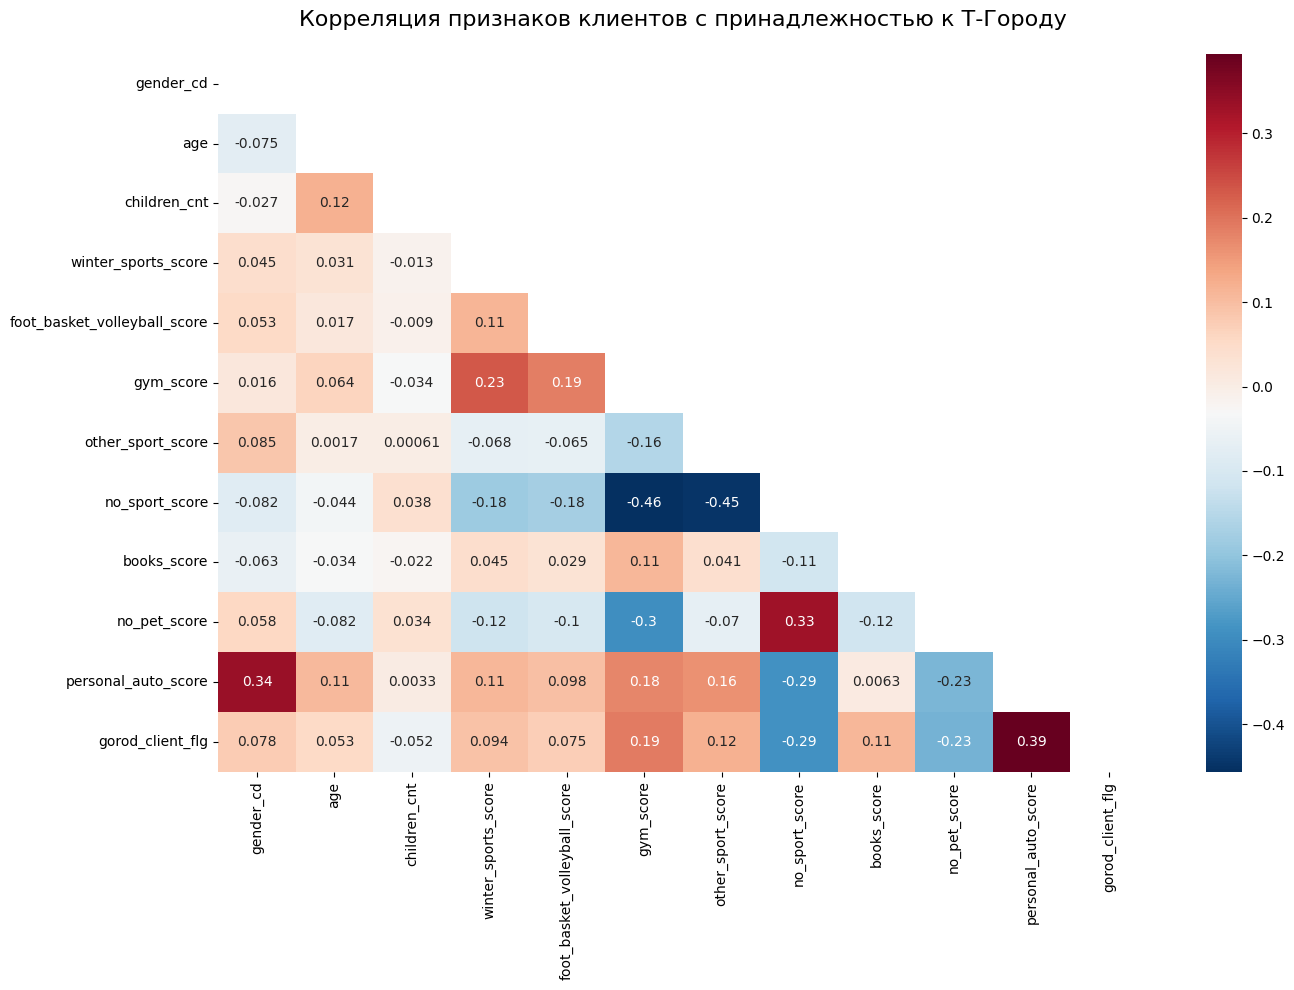

Топ признаков по корреляции с принадлежностью к Городу:
personal_auto_score             0.394375
no_sport_score                 -0.287668
no_pet_score                   -0.232466
gym_score                       0.191460
other_sport_score               0.119520
books_score                     0.109077
winter_sports_score             0.093611
gender_cd                       0.078129
foot_basket_volleyball_score    0.074814
age                             0.052999
Name: gorod_client_flg, dtype: float64


In [8]:
import seaborn as sns

client_features = [
    'gender_cd', 'age', 'children_cnt', 
    'winter_sports_score', 'foot_basket_volleyball_score', 
    'gym_score', 'other_sport_score', 'no_sport_score',
    'books_score', 'no_pet_score', 'personal_auto_score',
    'gorod_client_flg'
]
client_df = df.loc[:, client_features]
client_df['gender_cd'] = client_df['gender_cd'].map({'M': 1, 'F': 0})
correlation_matrix = client_df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, 
            mask=np.triu(np.ones_like(correlation_matrix, dtype=bool)),
            annot=True, 
            cmap='RdBu_r')

plt.title('Корреляция признаков клиентов с принадлежностью к Т-Городу', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print("Топ признаков по корреляции с принадлежностью к Городу:")
gorod_correlations = correlation_matrix['gorod_client_flg'].sort_values(key=abs, ascending=False)[1:11]
print(gorod_correlations)

Мы видим, что наибольшая корреляция между признаком 'клиент города' и признаками человека - это корреляция с параметром 'personal_auto_score'. Корреляция не всегда значит непосредственную причинно-следственную связь, но значение корреляции 0.4 может стать шагом к рассмотрению гипотезы о том, что значителньое преимущество использования сервиса заключается в выгоде, получаемой от покупки топлива, а для людей возраста до 25 лет (условно), это неактуально из-за отсутствия автомобиля.

Но мы всё ещё не можем быть уверены, что для нас актуально привлекать именно эту аудиторию. С одной стороны, сейчас прибыли от их привлечения может быть меньше. С другой стороны, в долгосрочной перспективе это выгодно, так как в долгосрочной перспективе денежный оборот молодых людей вырастет, а компания приобретёт их лояльность.

C:\Users\yaros\AppData\Local\Temp\ipykernel_24436\2720494030.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data2 = df.groupby('age_group')['sum_gmv'].mean()


Text(0.5, 1.0, 'Средние траты по возрастным группам (шаг 5 лет)')

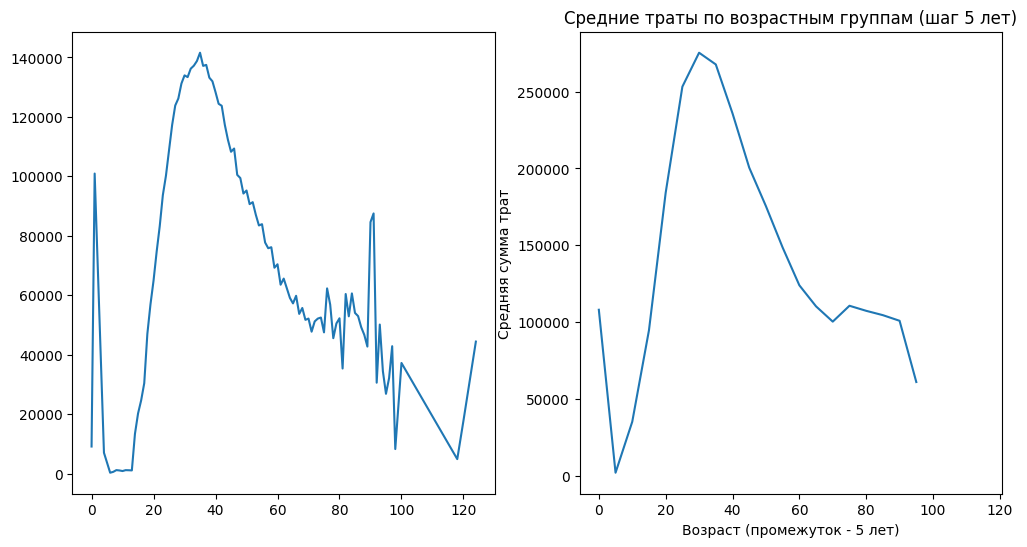

In [9]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
ages = [i for i in range(int(df['age'].min()), int(df['age'].max()) + 1, 5)]
df['sum_gmv'] = df[[col for col in df.columns if col.endswith('gmv')]].sum(axis=1)
grouped_data1 = df.groupby('age')['sum_gmv'].mean()
plt.plot(grouped_data1.index, grouped_data1.values)

df['age_group'] = pd.cut(df['age'], bins=ages)
df['sum_gmv'] = df[[col for col in df.columns if col.endswith('gmv')]].sum(axis=1)
grouped_data2 = df.groupby('age_group')['sum_gmv'].mean()

plt.subplot(1, 2, 2)
plt.plot([interval.left for interval in grouped_data2.index], grouped_data2.values)
plt.xlabel('Возраст (промежуток - 5 лет)')
plt.ylabel('Средняя сумма трат')
plt.title('Средние траты по возрастным группам (шаг 5 лет)')

Действительно, рассматриваемый возраст [18, 25] лет - момент начала быстрого роста трат, соответственно, нам может быть актуально привлечь эту аудиторию. Как её привлечь? Давайте посмотрим на интересы.

In [10]:
young_clients = df[df['age'].between(18, 25)]

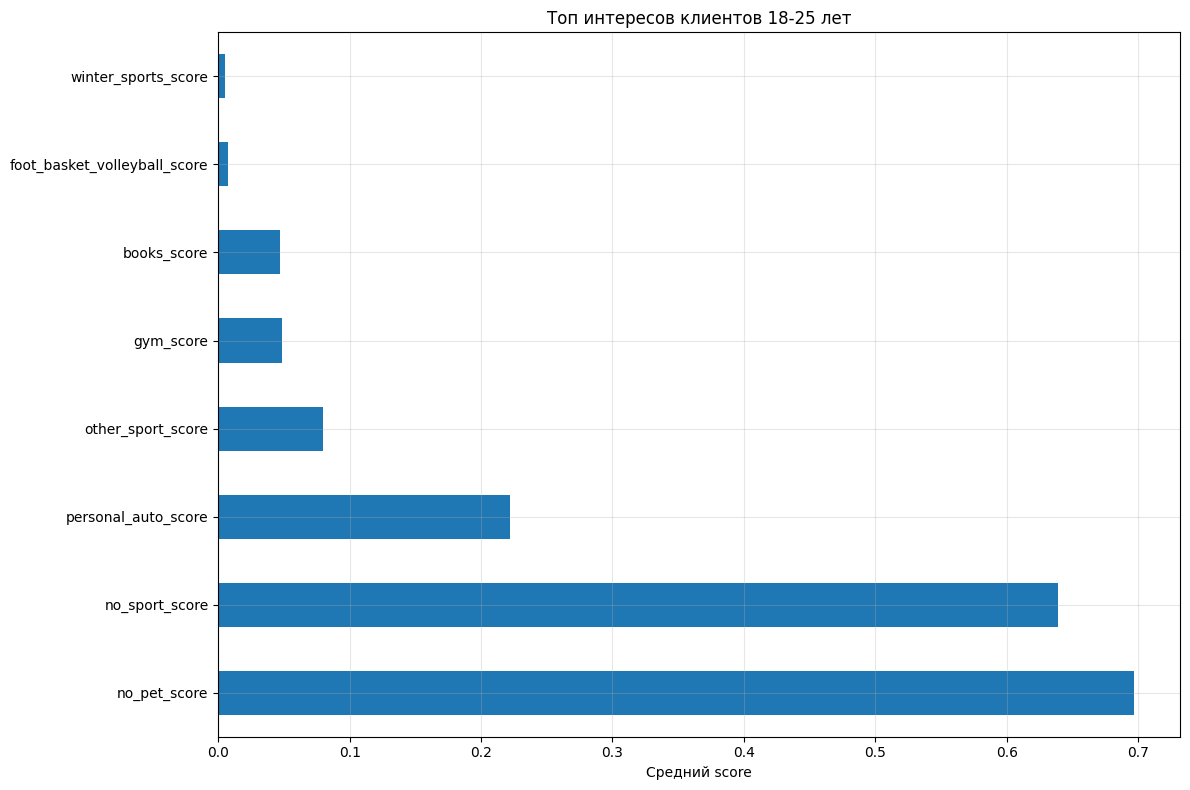

Рейтинг интересов молодых клиентов:
1. no_pet_score: 0.697
2. no_sport_score: 0.639
3. personal_auto_score: 0.222
4. other_sport_score: 0.079
5. gym_score: 0.049
6. books_score: 0.047
7. foot_basket_volleyball_score: 0.007
8. winter_sports_score: 0.005


In [23]:
interest_scores = [col for col in df.columns if 'score' in col]
interest_analysis = young_clients[interest_scores].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
interest_analysis.plot(kind='barh')
plt.title('Топ интересов клиентов 18-25 лет')
plt.xlabel('Средний score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Рейтинг интересов молодых клиентов:")
for i, (interest, score) in enumerate(interest_analysis.head(10).items(), 1):
    print(f"{i}. {interest}: {score:.3f}")

Очень жаль, эти данные почти ни о чём нам не говорят. Возможно, выборка не очень хорошая и модель, через которую предсказываалсь сфера интересов человека, на выборке из молодых людей ведёт себя не так предсказуемо. Давайте тогда посмотрим на реальные траты этой категории пользователей, чтобы определить, каким образом их можно привлечь к сервисам 'Города'.

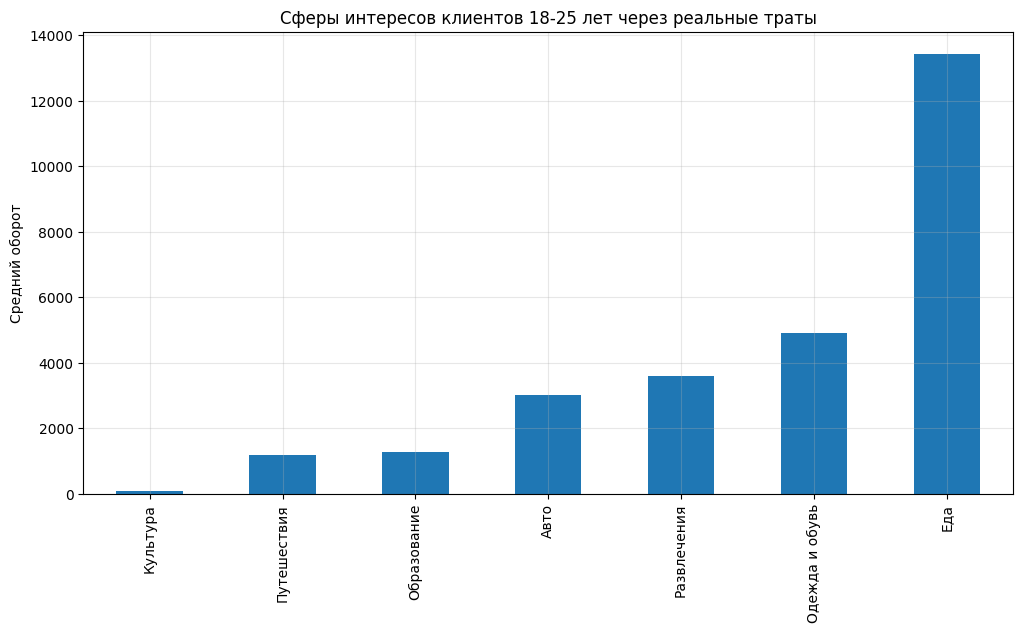

In [12]:
young_data= young_clients[[col for col in df.columns if col.endswith('gmv')]].mean()

grouped_features = {
    'Авто': young_data[['toplivo_gmv', 'avtouslugi_gmv', 'arenda_avto_gmv']].mean(),
    'Развлечения': young_data[['razvlechenija_gmv', 'kino_gmv', 'afisha_gmv']].mean(),
    'Еда': young_data[['restorany_gmv', 'fast_fud_gmv', 'supermarkety_gmv']].mean(),
    'Одежда и обувь': young_data[['odezhda_obuv_gmv']].mean(),
    'Путешествия': young_data[['aviabilety_gmv', 'zh_d_bilety_gmv', 'oteli_gmv', 'turagentstva_gmv']].mean(),
    'Образование': young_data[['obrazovanie_gmv']].mean(),
    'Культура': young_data[['iskusstvo_gmv', 'knigi_gmv']].mean()
}

plt.figure(figsize=(12, 6))
pd.Series(grouped_features).sort_values().plot(kind='bar')
plt.title('Сферы интересов клиентов 18-25 лет через реальные траты')
plt.ylabel('Средний оборот')
plt.grid(alpha=0.3)
plt.show()

Отлично, мы определили основные сферы трат молодых людей, теперь нужно понять, покрывает ли сервис "города" эти интересы. Для этого посмотрим, какой процент трат на еду у молодых людей происходит с помощью сервиса.

Процент трат на еду через сервис Города: 1.7%
Всего трат на еду: 7,451,000,200 у.е.
Траты через Город: 126,865,655 у.е.


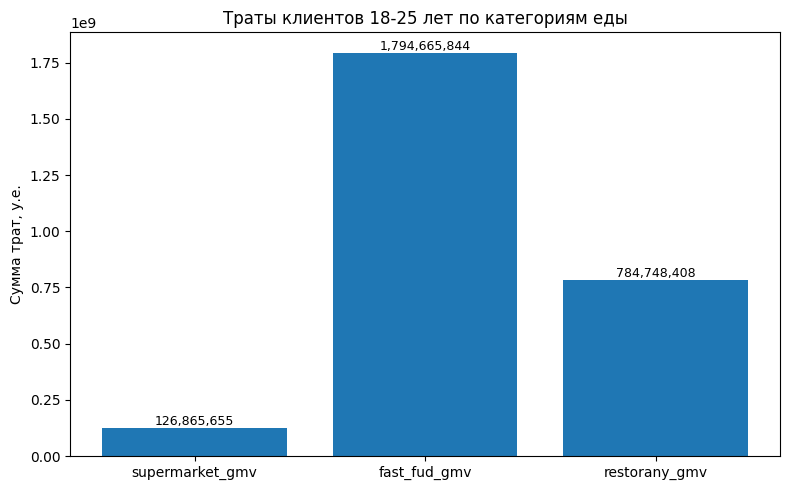

In [53]:
total_food_spending = (young_clients['restorany_gmv'].sum() + young_clients['fast_fud_gmv'].sum() + young_clients['supermarkety_gmv'].sum())
gorod_food_spending = young_clients['supermarket_gmv'].sum()
coverage_percentage = (gorod_food_spending / total_food_spending) * 100

print(f"Процент трат на еду через сервис Города: {coverage_percentage:.1f}%")
print(f"Всего трат на еду: {total_food_spending:,.0f} у.е.")
print(f"Траты через Город: {gorod_food_spending:,.0f} у.е.")

labels = ['supermarket_gmv', 'fast_fud_gmv', 'restorany_gmv']
values = [gorod_food_spending, young_clients['fast_fud_gmv'].sum(), young_clients['restorany_gmv'].sum()]
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)
plt.ylabel('Сумма трат, у.е.')
plt.title('Траты клиентов 18-25 лет по категориям еды')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:,.0f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Из данных графиков можно сделать первую гипотезу: 
***
Добавить в сервис "Продукты" доставку из ресторанов и фастфуда, что приведёт к повышению процента покупок через 'город'
***

Будем дальше пытаться повышать лояльность молодёжи к Т-банку. Давайте рассмотрим траты молодёжи на образование

In [22]:
students_education_spend = df[df['age'].between(18, 22)]['obrazovanie_gmv'].mean()
all_education_spend = df['obrazovanie_gmv'].mean()

print(f"Средние траты на образование (18-22): {students_education_spend:.0f}")
print(f"Стредние траты на образование (все): {all_education_spend:.0f}")


Средние траты на образование (18-22): 1316
Стредние траты на образование (все): 1074


То есть молодёжь значительно больше (приблизительно на 30%) тратит денег на образование, значит, выгода в тратах на образование может стать хорошим способом привлечь молодых людей к сервису города

In [ ]:
using_gorod = young_clients[young_clients['gorod_client_flg'] == 1]
education_ratio = using_gorod['obrazovanie_gmv'].notna().mean()
print(f"Молодые люди, пользующиеся 'городом', оплачивают образование: {education_ratio:.1%}")

Студенты, пользующиеся 'городом', оплачивают образование: 98.5%


In [39]:
education_stats = df['obrazovanie_gmv'].describe()
young_education = young_clients['obrazovanie_gmv'].sum()
total_education = df['obrazovanie_gmv'].sum()
students_in_gorod = len(young_clients[young_clients['gorod_client_flg'] == 1])

print(f"Молодежь 18-25 тратит на образование: {young_education:,.0f} у.е.")
print(f"Доля молодежи в общих тратах на образование: {young_education/total_education:.1%}")
print(f"Студентов в Городе: {students_in_gorod} чел.")
print(f"Средние траты на образование: {students_education_spend:.0f} у.е.")

Молодежь 18-25 тратит на образование: 236,256,511 у.е.
Доля молодежи в общих тратах на образование: 22.4%
Студентов в Городе: 79553 чел.
Средние траты на образование: 1316 у.е.


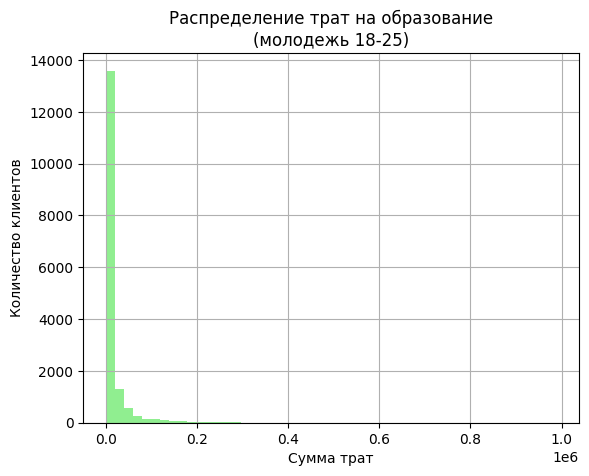

In [46]:
young_clients[young_clients['obrazovanie_gmv'] > 0]['obrazovanie_gmv'].hist(bins=50, color='lightgreen')
plt.title('Распределение трат на образование\n(молодежь 18-25)')
plt.xlabel('Сумма трат')
plt.ylabel('Количество клиентов')

plt.show()

***
Гипотеза: предлагать студентам, оплачивающим обучение через Т-банк, кэшбек 5% с оплаты учёбы, который можно потратить на сервисы 'Афиша' или 'Продукты' в 'городе', тем самым мотивируя их пользоваться сервисами
***